## 1. Importar Bibliotecas Necessárias

In [3]:
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregar o Arquivo CSV

In [4]:
# Carregar dados
df = pd.read_csv('../data/processed/can-data-decoded-2026-01-07.csv')

# Converter timestamp para datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')

print("Arquivo carregado com sucesso!")
print(f"Total de registros: {len(df):,}")

Arquivo carregado com sucesso!
Total de registros: 31,102


## 3. Exploração Inicial dos Dados

In [5]:
# Visualizar primeiras linhas
print("Primeiras 10 linhas do dataset:")
df.head(10)

Primeiras 10 linhas do dataset:


,timestamp,voltage,current,soc,soh,batteryTemperature,motorSpeedRpm,motorTorque,motorTemperature,controllerTemperature
0,2026-01-07 16:17:35.470000+00:00,73.9,0.2,51.0,100.0,28.0,0,0.0,-26,26
1,2026-01-07 16:17:35.470000+00:00,73.9,0.2,51.0,100.0,28.0,0,0.0,-26,26
2,2026-01-07 16:17:35.470000+00:00,73.9,0.2,51.0,100.0,28.0,0,0.0,-26,26
3,2026-01-07 16:17:35.470000+00:00,73.9,0.2,51.0,100.0,28.0,0,0.0,-26,26
4,2026-01-07 16:17:35.470000+00:00,73.9,0.2,51.0,100.0,28.0,0,0.0,-26,26
5,2026-01-07 16:17:35.470000+00:00,73.9,0.2,51.0,100.0,28.0,0,0.0,-26,26
6,2026-01-07 16:17:35.470000+00:00,73.9,0.2,51.0,100.0,28.0,0,0.0,-26,26
7,2026-01-07 16:17:35.470000+00:00,73.9,0.2,51.0,100.0,28.0,0,0.0,-26,26
8,2026-01-07 16:17:35.470000+00:00,73.9,0.1,51.0,100.0,28.0,0,0.0,-26,26
9,2026-01-07 16:17:35.470000+00:00,73.9,0.1,51.0,100.0,28.0,0,0.0,-26,26


In [6]:
# Informações sobre o dataset
print("Informações do Dataset:")
print(f"Shape: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nTipos de dados:")
df.info()

Informações do Dataset:
Shape: (31102, 10)

Colunas: ['timestamp', 'voltage', 'current', 'soc', 'soh', 'batteryTemperature', 'motorSpeedRpm', 'motorTorque', 'motorTemperature', 'controllerTemperature']

Tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31102 entries, 0 to 31101
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   timestamp              31102 non-null  datetime64[ns, UTC]
 1   voltage                31102 non-null  float64            
 2   current                31102 non-null  float64            
 3   soc                    31102 non-null  float64            
 4   soh                    31102 non-null  float64            
 5   batteryTemperature     31102 non-null  float64            
 6   motorSpeedRpm          31102 non-null  int64              
 7   motorTorque            31102 non-null  float64            
 8   motorTemperature       3110

## 4. Análise Estatística Descritiva

In [7]:
# Colunas numéricas para análise
numeric_cols = ['voltage', 'current', 'soc', 'soh', 'batteryTemperature', 
                'motorSpeedRpm', 'motorTorque', 'motorTemperature', 'controllerTemperature']

# Estatísticas descritivas
print("Estatísticas Descritivas:")
df[numeric_cols].describe().round(2)

Estatísticas Descritivas:


,voltage,current,soc,soh,batteryTemperature,motorSpeedRpm,motorTorque,motorTemperature,controllerTemperature
count,31102.00,31102.00,31102.00,31102.0,31102.00,31102.00,31102.0,31102.00,31102.00
mean,77.73,15.16,79.47,100.0,31.91,217.11,0.0,98.68,52.22
std,2.78,22.41,14.93,0.0,4.60,169.99,0.0,121.52,17.88
min,71.40,0.00,51.00,100.0,26.00,0.00,0.0,-40.00,20.00
25%,75.90,0.20,67.00,100.0,27.00,1.00,0.0,-32.00,37.00
50%,77.80,0.80,79.00,100.0,32.00,239.00,0.0,208.00,59.00
75%,80.00,28.30,94.00,100.0,36.00,364.00,0.0,210.00,68.00
max,82.40,97.10,100.00,100.0,39.00,601.00,0.0,214.00,77.00


## 5. Análise de Distribuição (Skewness e Kurtosis)

In [8]:
# Calcular skewness (assimetria) e kurtosis para cada coluna
distribution_stats = pd.DataFrame({
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
})

print("Análise de Forma da Distribuição:")
print("\nSkewness: > 0 = cauda à direita, < 0 = cauda à esquerda")
print("Kurtosis: > 0 = caudas pesadas, < 0 = caudas leves")
print()
distribution_stats.round(3)

Análise de Forma da Distribuição:

Skewness: > 0 = cauda à direita, < 0 = cauda à esquerda
Kurtosis: > 0 = caudas pesadas, < 0 = caudas leves



,Skewness,Kurtosis
voltage,0.014,-0.706
current,1.231,0.021
soc,-0.093,-1.320
soh,0.000,0.000
batteryTemperature,0.217,-1.360
motorSpeedRpm,-0.009,-1.296
motorTorque,0.000,0.000
motorTemperature,-0.156,-1.972
controllerTemperature,-0.603,-1.104


## 6. Histogramas de Distribuição

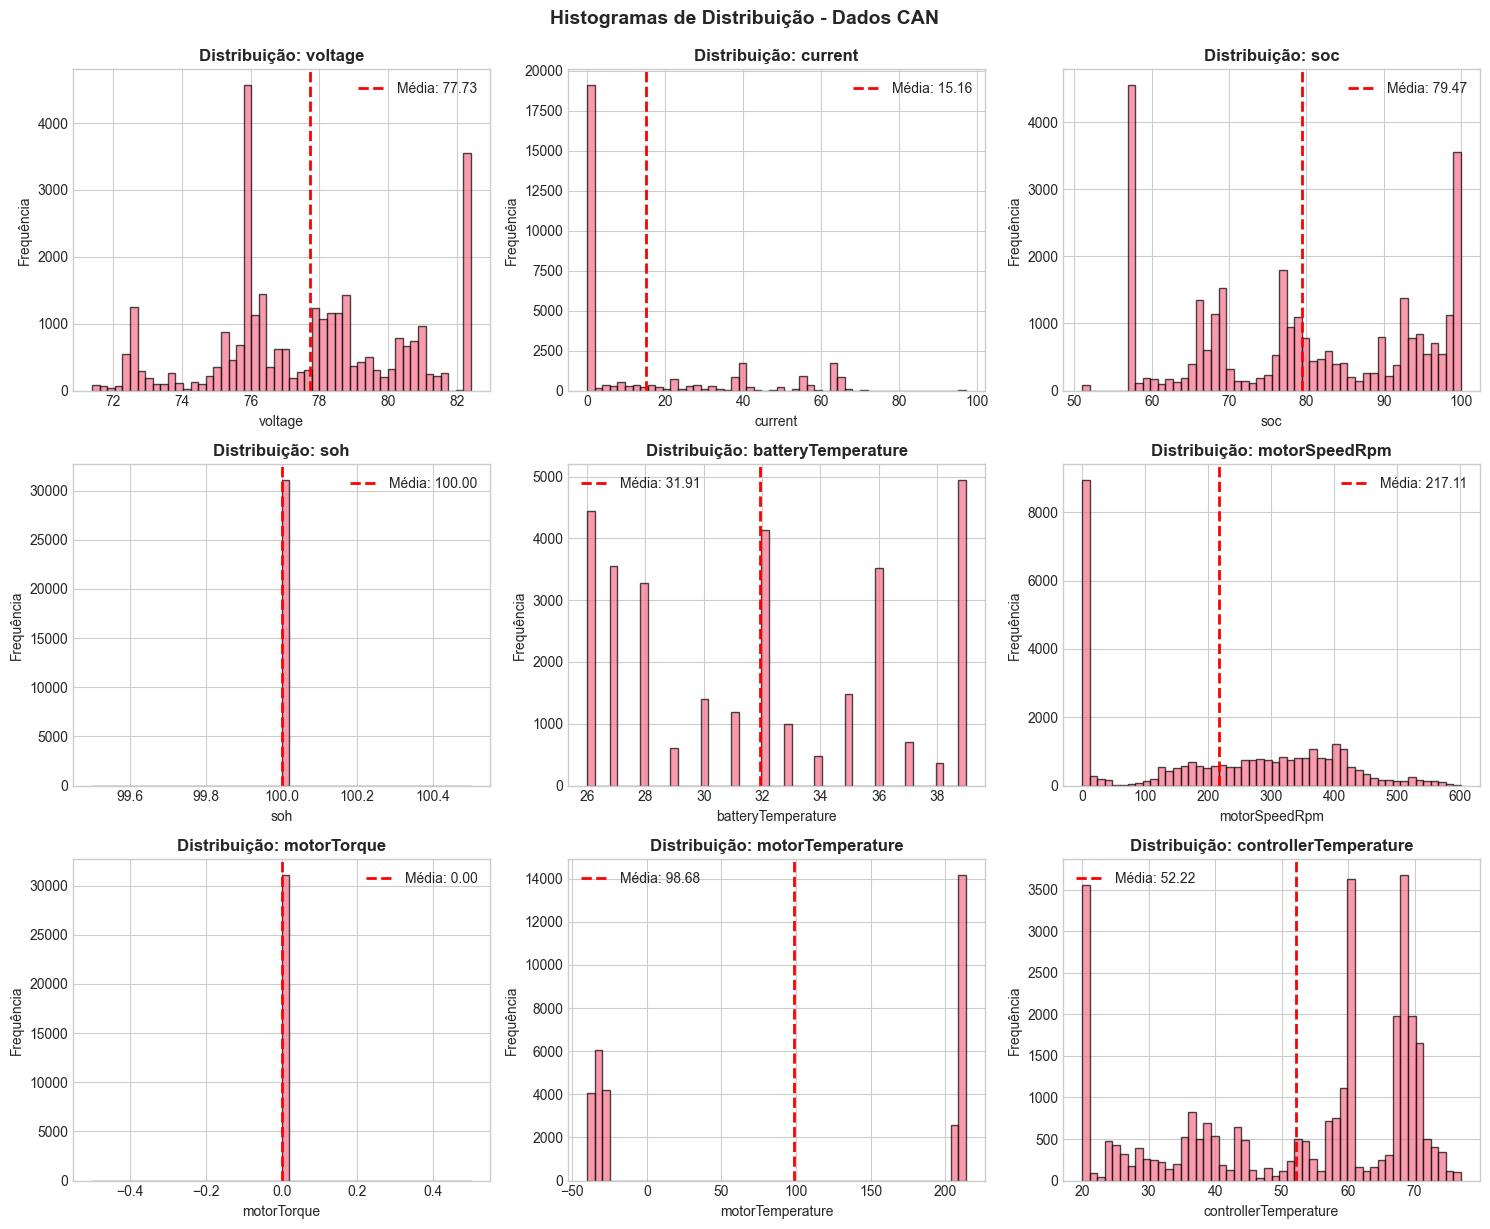

In [9]:
# Criar histogramas para todas as colunas numéricas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = df[col].dropna()
    
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    
    # Adicionar linha da média
    mean_val = data.mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_val:.2f}')
    ax.legend()

plt.tight_layout()
plt.suptitle('Histogramas de Distribuição - Dados CAN', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 7. Box Plots Individuais

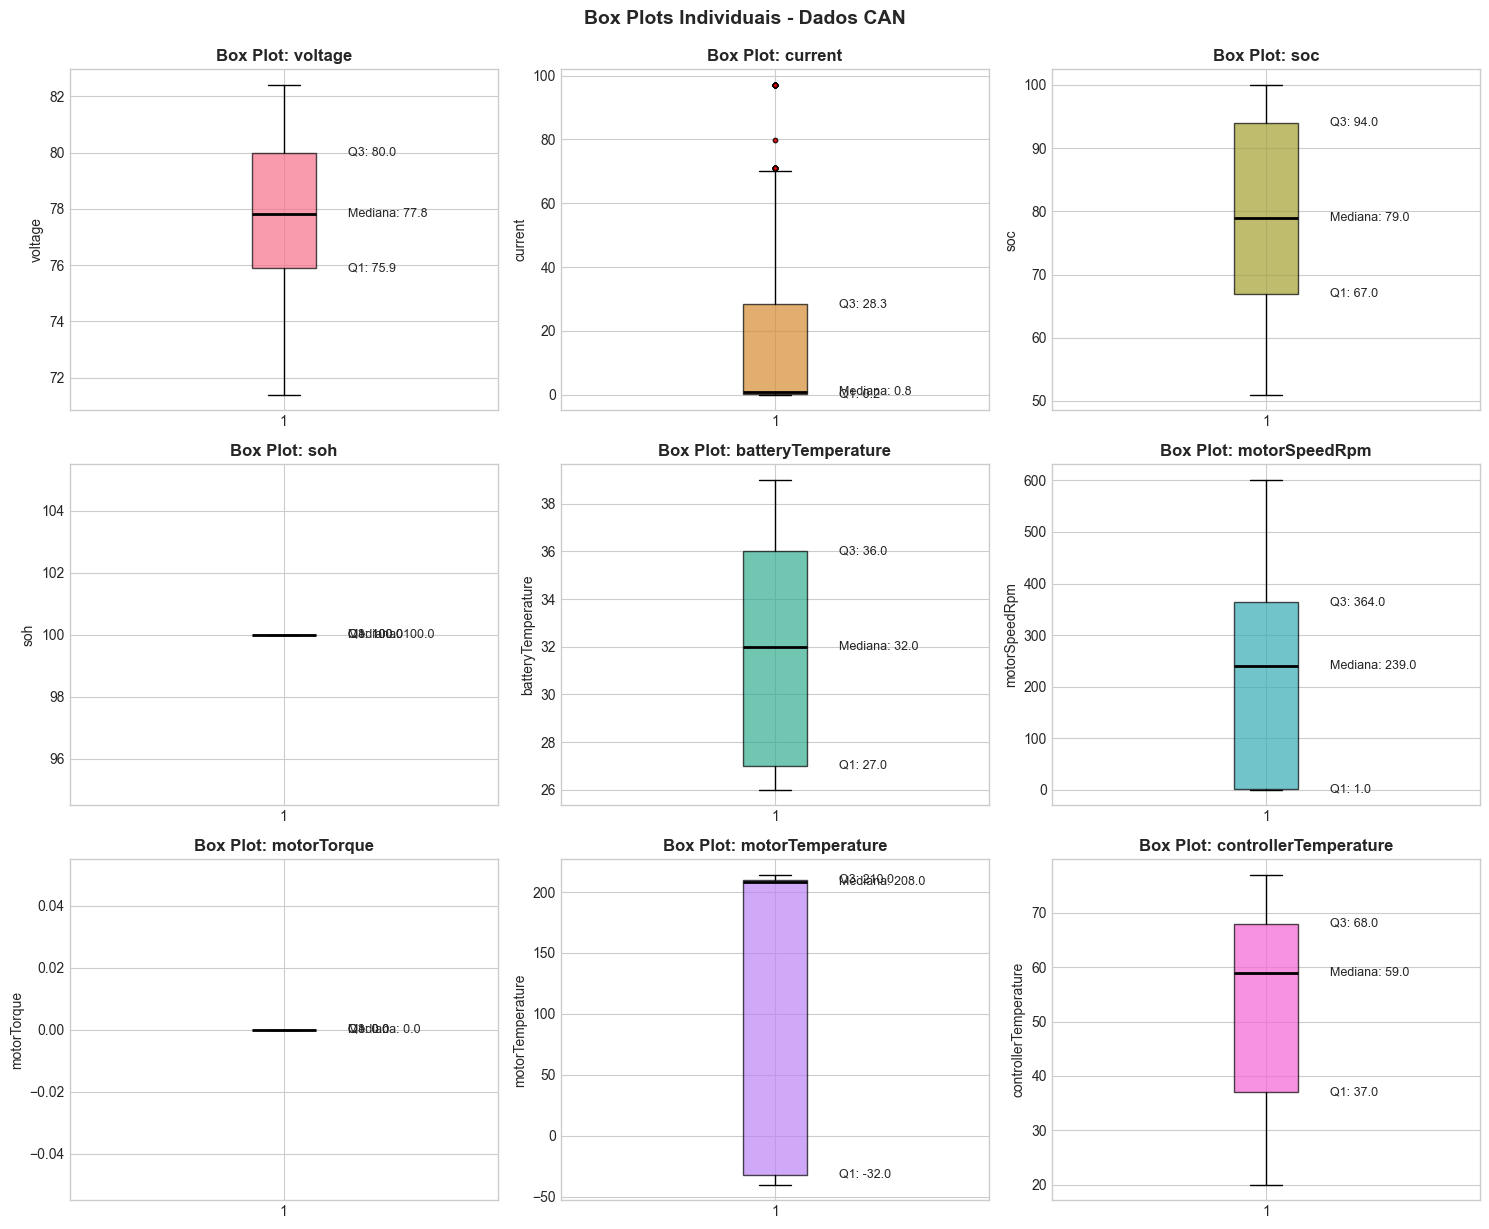

In [10]:
# Criar box plots individuais para cada coluna
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

colors = sns.color_palette("husl", len(numeric_cols))

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = df[col].dropna()
    
    box = ax.boxplot(data, patch_artist=True, 
                     boxprops=dict(facecolor=colors[idx], alpha=0.7),
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
    
    ax.set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)
    
    # Adicionar estatísticas no gráfico
    median = data.median()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    ax.text(1.15, median, f'Mediana: {median:.1f}', fontsize=9, va='center')
    ax.text(1.15, q1, f'Q1: {q1:.1f}', fontsize=9, va='center')
    ax.text(1.15, q3, f'Q3: {q3:.1f}', fontsize=9, va='center')

plt.tight_layout()
plt.suptitle('Box Plots Individuais - Dados CAN', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 8. Box Plots Combinados por Categoria

### 8.1 Dados da Bateria

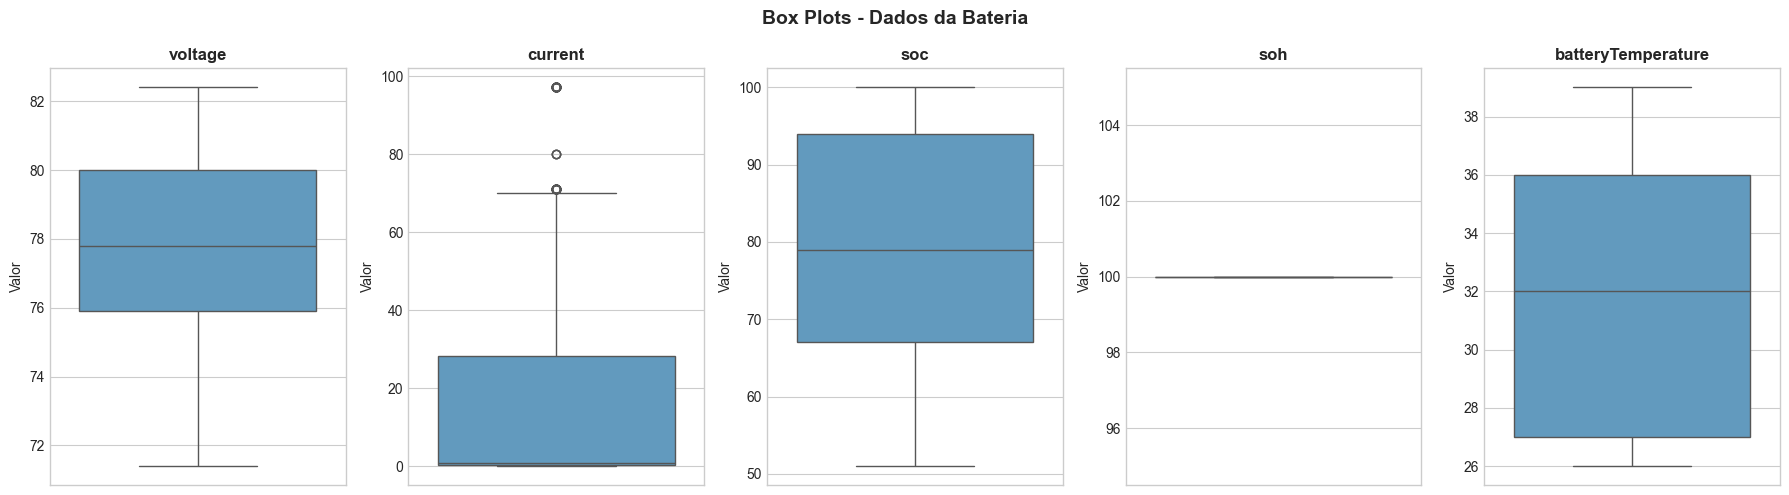

In [11]:
# Box plots para dados da bateria
battery_cols = ['voltage', 'current', 'soc', 'soh', 'batteryTemperature']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for idx, col in enumerate(battery_cols):
    ax = axes[idx]
    data = df[col].dropna()
    
    sns.boxplot(y=data, ax=ax, color=sns.color_palette("Blues")[3])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Box Plots - Dados da Bateria', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Dados do Motor Controller

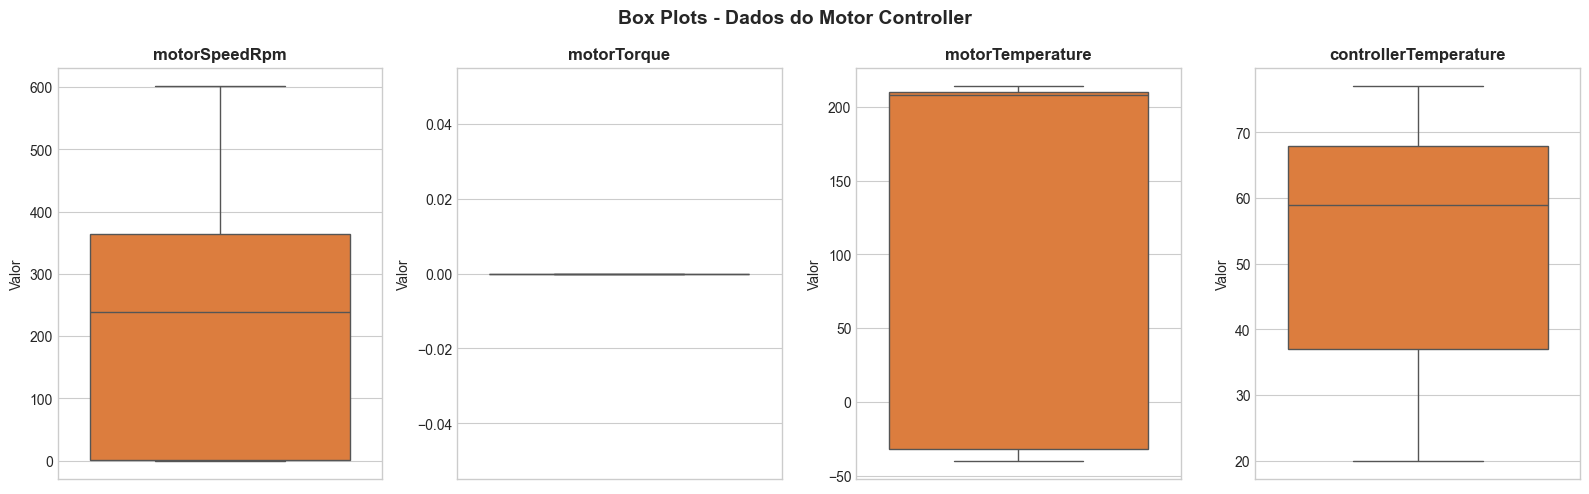

In [12]:
# Box plots para dados do motor controller
motor_cols = ['motorSpeedRpm', 'motorTorque', 'motorTemperature', 'controllerTemperature']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, col in enumerate(motor_cols):
    ax = axes[idx]
    data = df[col].dropna()
    
    sns.boxplot(y=data, ax=ax, color=sns.color_palette("Oranges")[3])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Box Plots - Dados do Motor Controller', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Comparação de Temperaturas

/var/folders/60/n8m7rtz14nq1qy7tkbtk9zqc0000gn/T/ipykernel_2491/2083537440.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sensor', y='Temperatura (°C)', data=temp_data, palette='coolwarm', ax=ax)
/var/folders/60/n8m7rtz14nq1qy7tkbtk9zqc0000gn/T/ipykernel_2491/2083537440.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Bateria', 'Motor', 'Controller'])


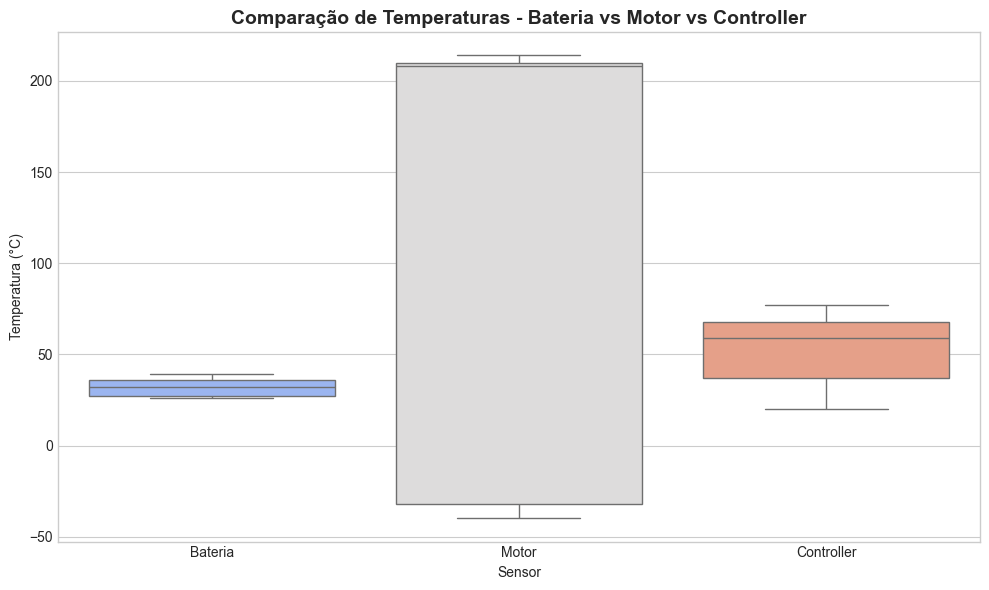

In [13]:
# Comparação de todas as temperaturas
temp_cols = ['batteryTemperature', 'motorTemperature', 'controllerTemperature']

# Preparar dados para box plot comparativo
temp_data = df[temp_cols].melt(var_name='Sensor', value_name='Temperatura (°C)')

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='Sensor', y='Temperatura (°C)', data=temp_data, palette='coolwarm', ax=ax)
ax.set_title('Comparação de Temperaturas - Bateria vs Motor vs Controller', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Bateria', 'Motor', 'Controller'])
plt.tight_layout()
plt.show()